# CNN Training Notebook

### 0. Import Library & Dataset

In [1]:
# Standard libraries
import os
import sys
import itertools
import time
import json

from pathlib import Path

# Data Processing
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt

# Evaluasi Model
from sklearn.metrics import f1_score, classification_report

# Deep Learning
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print('TF: ', tf.__version__)
print('GPU: ', gpus)

I0000 00:00:1778676580.211640     459 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778676580.848153     459 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778676584.790905     459 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF:  2.21.0
GPU:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
src = Path(os.getcwd())

while not (src / 'src').exists() and src != src.parent:
    src = src.parent

if not (src / 'src').exists():
    wsl_path = Path('/mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap')
    if wsl_path.exists():
        src = wsl_path
    else:
        raise RuntimeError(f"Tidak bisa menemukan project root! CWD: {os.getcwd()}")

sys.path.insert(0, str(src))
os.chdir(src)
print("Project root:", src)

Project root: /mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap


In [3]:
DATA_DIR = src / 'data' / 'cnn'
MODEL_DIR = src / 'models' / 'cnn'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = DATA_DIR / 'seg_train' / 'seg_train'
TEST_DIR  = DATA_DIR / 'seg_test' / 'seg_test'

print("TRAIN_DIR:", TRAIN_DIR)
print("Exists:", TRAIN_DIR.exists())

TRAIN_DIR: /mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap/data/cnn/seg_train/seg_train
Exists: True


In [4]:
import os
print("CWD:", os.getcwd())
print("TRAIN_DIR:", TRAIN_DIR)
print("Exists:", TRAIN_DIR.exists())


CWD: /mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap
TRAIN_DIR: /mnt/c/Users/nazwa/Coding/Semester-6/Tubes2_ML_2_Karyawan_Tetap/data/cnn/seg_train/seg_train
Exists: True


### 1. Load Dataset

In [5]:
CLASSES = []

for iterdir in TRAIN_DIR.iterdir():
    if iterdir.is_dir():
        CLASSES.append(iterdir.name)

CLASSES.sort()
print('Classes are ', CLASSES)

# 80:20 Split untuk Train & Test dataset
# Define Variables
IMG_SIZE = 100
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 6

# 1. Train
train_split_ = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, 
                                                           image_size = (IMG_SIZE, IMG_SIZE),
                                                           batch_size = BATCH_SIZE,
                                                           label_mode = 'int',
                                                           seed = 42,
                                                           class_names = CLASSES,
                                                           validation_split  = 0.2,
                                                           subset = 'training',
                                                           )

# 2. Validation
validate_split_ = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR,
                                                              image_size = (IMG_SIZE, IMG_SIZE),
                                                              batch_size = BATCH_SIZE,
                                                              label_mode = 'int',
                                                              seed = 42,
                                                              class_names = CLASSES,
                                                              validation_split = 0.2,
                                                              subset = 'validation',
                                                              )

# 3. Test
test_split_ = tf.keras.utils.image_dataset_from_directory(TEST_DIR,
                                                           image_size = (IMG_SIZE, IMG_SIZE),
                                                           batch_size = BATCH_SIZE,
                                                           label_mode = 'int',
                                                           shuffle = False,
                                                           class_names = CLASSES,
                                                           )

norm = tf.keras.layers.Rescaling(1./255)
train_ds = train_split_.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds = validate_split_.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_split_.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)

label_list = []
for gambar, label in test_ds:
    label_numpy = label.numpy()

    label_list.append(label_numpy)

y_test = np.concatenate(label_list)
print(f'Train: {len(train_ds)}')
print(f'Validation: {len(val_ds)}')
print(f'Test: {len(y_test)}')

Classes are  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1778676589.059824     459 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Train: 351
Validation: 88
Test: 3000


### 2. CNN

In [6]:
GRID = {
    'n_conv':  [2, 4],
    'filters': [[32, 64], [64, 128]],
    'k_size': [3, 5],
    'pool': ['max', 'avg']
}

configs = list(itertools.product(GRID['n_conv'],
                                 GRID['filters'],
                                 GRID['k_size'],
                                 GRID['pool']
                                 ))

for i, (n, fltrs, krnl, pl) in enumerate(configs):
    print(f' [{i}] n_conv = {n}, filters={fltrs}, k_size={krnl}, pool={pl}')

 [0] n_conv = 2, filters=[32, 64], k_size=3, pool=max
 [1] n_conv = 2, filters=[32, 64], k_size=3, pool=avg
 [2] n_conv = 2, filters=[32, 64], k_size=5, pool=max
 [3] n_conv = 2, filters=[32, 64], k_size=5, pool=avg
 [4] n_conv = 2, filters=[64, 128], k_size=3, pool=max
 [5] n_conv = 2, filters=[64, 128], k_size=3, pool=avg
 [6] n_conv = 2, filters=[64, 128], k_size=5, pool=max
 [7] n_conv = 2, filters=[64, 128], k_size=5, pool=avg
 [8] n_conv = 4, filters=[32, 64], k_size=3, pool=max
 [9] n_conv = 4, filters=[32, 64], k_size=3, pool=avg
 [10] n_conv = 4, filters=[32, 64], k_size=5, pool=max
 [11] n_conv = 4, filters=[32, 64], k_size=5, pool=avg
 [12] n_conv = 4, filters=[64, 128], k_size=3, pool=max
 [13] n_conv = 4, filters=[64, 128], k_size=3, pool=avg
 [14] n_conv = 4, filters=[64, 128], k_size=5, pool=max
 [15] n_conv = 4, filters=[64, 128], k_size=5, pool=avg


In [7]:
def build_cnn(n_conv, filters, k_size, pool):
    if pool == 'max':
        PoolLayer = tf.keras.layers.MaxPooling2D
    else:
        PoolLayer = tf.keras.layers.AveragePooling2D

    name_model = f'cnn_c{n_conv}_k{k_size}_{pool}'
    model = tf.keras.Sequential(name=name_model)
    model.add(tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

    for i in range (n_conv):
        fltr = filters[i % len(filters)]
        model.add(tf.keras.layers.Conv2D(fltr, k_size, activation='relu', padding='same'))
        model.add(PoolLayer(2, 2))

    model.add(tf.keras.layers.GlobalAveragePooling2D())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [8]:
HIST_PATH = MODEL_DIR / 'histories.json'
history = {}

if HIST_PATH.exists():
    with open(HIST_PATH) as filepath:
        history = json.load(filepath)

result_list = []
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

for i, (n_conv, fltrs, krnl, pl) in enumerate(configs):
    tag = f'c{n_conv}_f{"_".join(map(str,fltrs))}_k{krnl}_{pl}'

    save_path = MODEL_DIR / f'arch_{i:02d}_{tag}.h5'
    print(f'[{i+1}/16] {tag}', end=' ... ')

    if save_path.exists():
        model = tf.keras.models.load_model(save_path)
        print('model loaded (1)')

    else:
        model = build_cnn(n_conv, fltrs, krnl, pl)
        hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=[early_stop], verbose=0)
        
        model.save(save_path)
        history[tag] = hist.history

        with open(HIST_PATH, 'w') as filepath:
            json.dump(history, filepath)
        print(f'trained {len(hist.history["loss"])} epochs')

    y_pred = model.predict(test_ds, verbose=0).argmax(1)
    f1 = f1_score(y_test, y_pred, average='macro')

    result_list.append({
        'idx': i, 'tag': tag,
        'n_conv': n_conv, 'filters': str(fltrs),
        'k_size': krnl, 'pool': pl,
        'f1_macro': round(f1, 4),
        'params': model.count_params(),
    })
    print(f'  - F1: {f1:.4f}')

with open(MODEL_DIR / 'results.json', 'w') as fp:
    json.dump(result_list, fp, indent=2)
print('\nDone!')  


[1/16] c2_f32_64_k3_max ... 

I0000 00:00:1778676600.677824     563 service.cc:153] XLA service 0x7f917404fa10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778676600.677923     563 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778676600.725583     563 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


model loaded (1)


I0000 00:00:1778676600.822458     563 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778676606.315096     563 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  - F1: 0.7069
[2/16] c2_f32_64_k3_avg ... 

...

trained 5 epochs
  - F1: 0.5929
[15/16] c4_f64_128_k5_max ... 

I0000 00:00:1778677605.269066     561 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_176521__.49
I0000 00:00:1778677633.175229     562 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_176521__.49


trained 5 epochs
  - F1: 0.5669
[16/16] c4_f64_128_k5_avg ... 

I0000 00:00:1778677732.085488     565 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_189000__.33
I0000 00:00:1778677750.475912     561 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_189000__.33


trained 5 epochs
  - F1: 0.5762

Done!


### 3. Hasil Training

In [9]:
df = pd.DataFrame(result_list).sort_values('f1_macro', ascending=False).reset_index(drop=True)
display(df[['tag','n_conv','filters','k_size','pool','f1_macro','params']])

best_row = df.iloc[0]
print(f'\nArsitektur terbaik: {best_row["tag"]} (F1={best_row["f1_macro"]:.4f})')

,tag,n_conv,filters,k_size,pool,f1_macro,params
0,c2_f32_64_k5_max,2,"[32, 64]",5,max,0.7978,62790
1,c2_f32_64_k3_max,2,"[32, 64]",3,max,0.7069,28486
2,c4_f64_128_k3_max,4,"[64, 128]",3,max,0.6184,240582
3,c4_f32_64_k5_max,4,"[32, 64]",5,max,0.5930,165286
4,c4_f64_128_k3_avg,4,"[64, 128]",3,avg,0.5929,240582
5,c4_f32_64_k5_avg,4,"[32, 64]",5,avg,0.5866,165286
6,c4_f64_128_k5_avg,4,"[64, 128]",5,avg,0.5762,636870
7,c4_f64_128_k5_max,4,"[64, 128]",5,max,0.5669,636870
8,c2_f64_128_k5_max,2,"[64, 128]",5,max,0.5638,227078
9,c2_f64_128_k5_avg,2,"[64, 128]",5,avg,0.5559,227078



Arsitektur terbaik: c2_f32_64_k5_max (F1=0.7978)


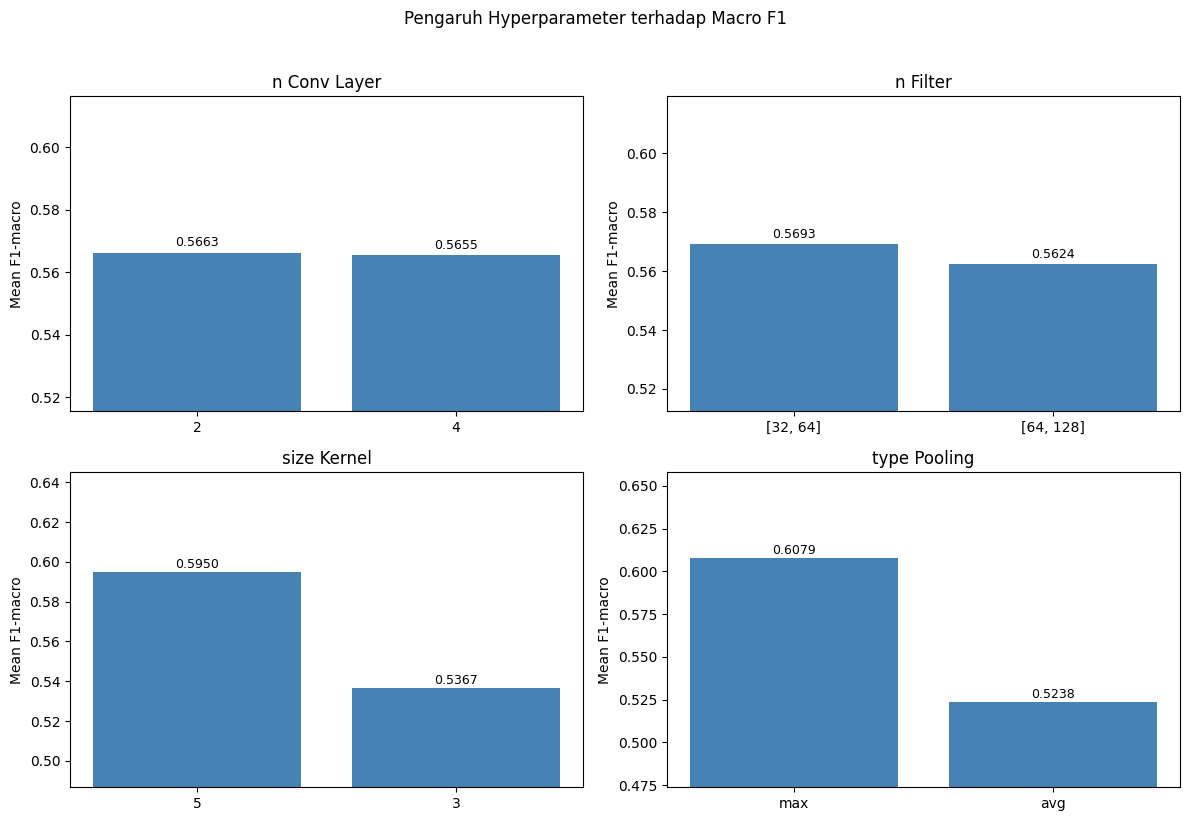

In [10]:
# Rata-rata F1 per nilai hyperparameter
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
hparams   = [('n_conv','n Conv Layer'), ('filters','n Filter'),
             ('k_size','size Kernel'), ('pool','type Pooling')]

for ax, (col, title) in zip(axes.flat, hparams):
    grp = df.groupby(col)['f1_macro'].mean().sort_values(ascending=False)

    ax.bar(grp.index.astype(str), grp.values, color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Mean F1-macro')
    ax.set_ylim(max(0, (grp.min()-0.05)), (grp.max()+0.05))

    for j, (x, v) in enumerate(zip(grp.index.astype(str), grp.values)):
        ax.text(j, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Pengaruh Hyperparameter terhadap Macro F1', y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'hyperparam_analysis.png', bbox_inches='tight')
plt.show()

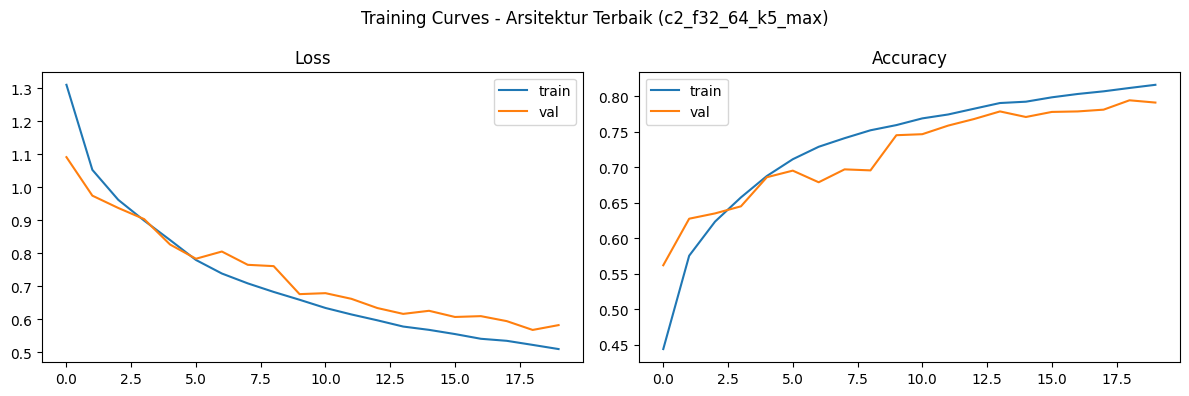

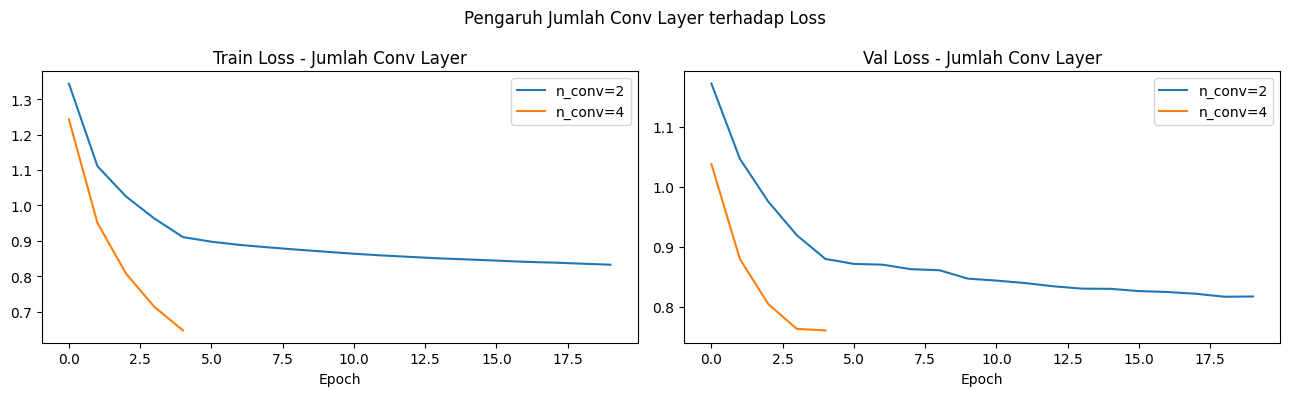

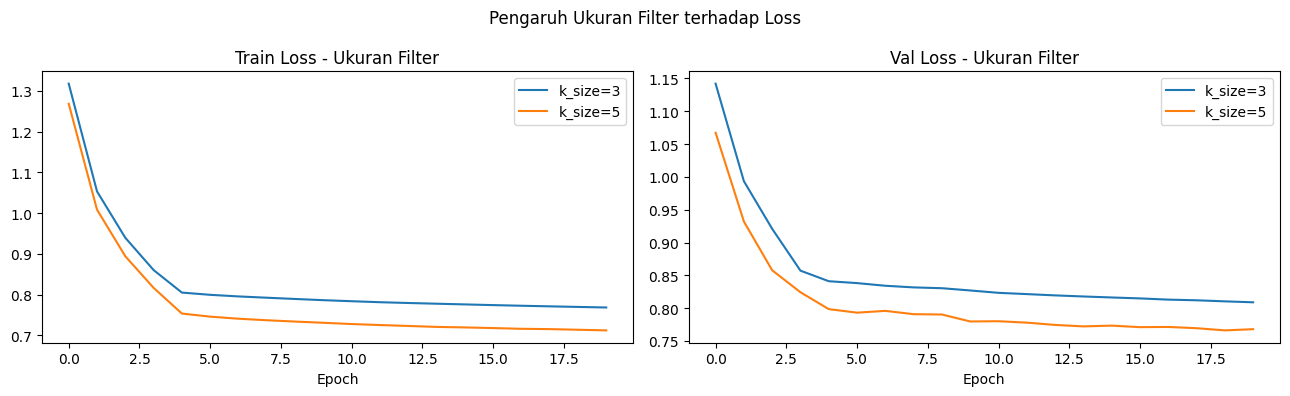

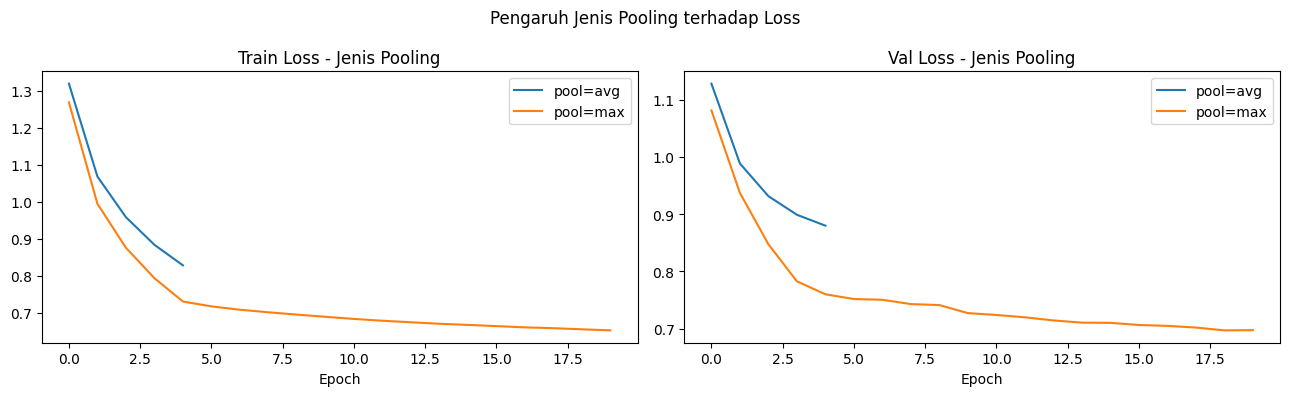

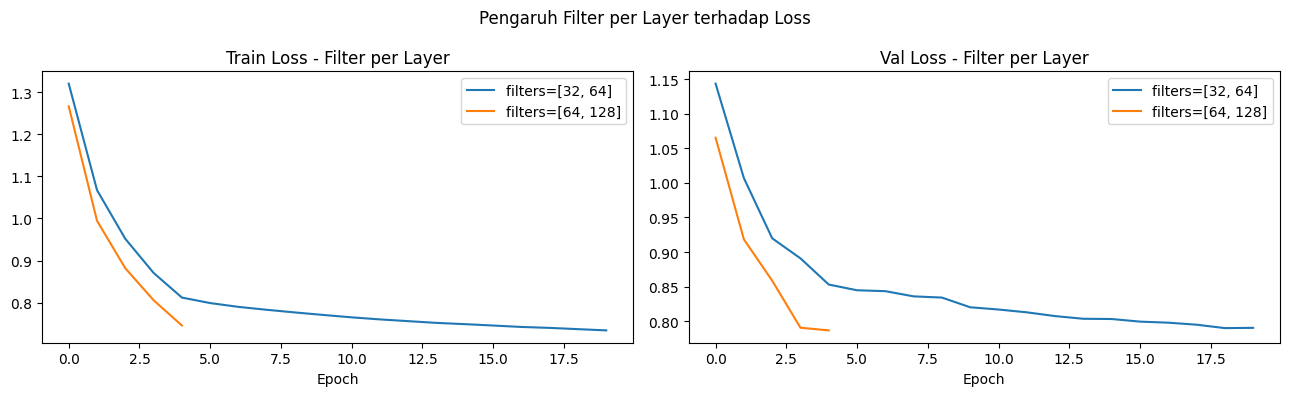

In [11]:
HIST_PATH = MODEL_DIR / 'histories.json'
if HIST_PATH.exists():
    with open(HIST_PATH) as fp:
        history.update(json.load(fp))

best_tag = best_row['tag']
if best_tag in history:
    hist = history[best_tag]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(hist['loss'], label='train')
    ax1.plot(hist['val_loss'], label='val')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(hist['accuracy'], label='train')
    ax2.plot(hist['val_accuracy'], label='val')
    ax2.set_title('Accuracy')
    ax2.legend()

    plt.suptitle(f'Training Curves - Arsitektur Terbaik ({best_tag})')
    plt.tight_layout()
    plt.savefig(MODEL_DIR / 'best_curves.png', bbox_inches='tight')
    plt.show()

else:
    print("Tidak memiliki history")


if history:

    hparam_groups = {
        'n_conv':  {'label': 'Jumlah Conv Layer', 'vals': sorted({result['n_conv'] for result in result_list})},
        'k_size':  {'label': 'Ukuran Filter', 'vals': sorted({result['k_size'] for result in result_list})},
        'pool':    {'label': 'Jenis Pooling', 'vals': sorted({result['pool'] for result in result_list})},
        'filters': {'label': 'Filter per Layer', 'vals': sorted({result['filters'] for result in result_list})},
    }

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for param, info in hparam_groups.items():
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

        for ci, val in enumerate(info['vals']):
            subset = []
            for result in result_list:
                if str(result[param]) == str(val):
                    subset.append(result)

            all_vl = []
            all_tl = []
            for s in subset:
                if s['tag'] in history:
                    vl = history[s['tag']]['val_loss']
                    tl = history[s['tag']]['loss']

                    all_vl.append(vl)
                    all_tl.append(tl)

            if not all_vl:
                continue
            
            max_e = 0
            for vl in all_vl:
                len_vl = len(vl)

                if (len_vl > max_e):
                    max_e = len_vl
                    
            pad = lambda arr: [v + [v[-1]] * (max_e - len(v)) for v in arr]
            mean_vl = np.array(pad(all_vl)).mean(axis=0)
            mean_tl = np.array(pad(all_tl)).mean(axis=0)

            c = colors[ci % len(colors)]
            ax1.plot(mean_tl, label=f'{param}={val}', color=c)
            ax2.plot(mean_vl, label=f'{param}={val}', color=c)

        ax1.set_title(f'Train Loss - {info["label"]}'); ax1.legend(); ax1.set_xlabel('Epoch')
        ax2.set_title(f'Val Loss - {info["label"]}');   ax2.legend(); ax2.set_xlabel('Epoch')
        plt.suptitle(f'Pengaruh {info["label"]} terhadap Loss')

        plt.tight_layout()
        plt.savefig(MODEL_DIR / f'loss_curves_{param}.png', bbox_inches='tight')
        plt.show()

else:
    print('Tidak ada history tersimpan.')


### 4. Keras v. From-Scratch

In [12]:
from src.cnn.model import CNNFromScratch

best_path  = MODEL_DIR / f'arch_{best_row["idx"]:02d}_{best_tag}.h5'
keras_model = tf.keras.models.load_model(best_path)

X_test_np = np.concatenate([x.numpy() for x, _ in test_ds])
print(f'X_test shape: {X_test_np.shape}')

# 1. Keras
time_start = time.time()

y_keras = keras_model.predict(test_ds, verbose=0).argmax(1)
t_keras = time.time() - time_start
f1_keras = f1_score(y_test, y_keras, average='macro')


# 2. Scracth
scratch = CNNFromScratch.from_keras(keras_model)
time_start = time.time()

y_scratch = scratch.predict_classes(X_test_np)
t_scratch = time.time() - time_start
f1_scratch = f1_score(y_test, y_scratch, average='macro')

print(f'\n{"":20s} {"F1-macro":>10s} {"Waktu (s)":>10s}')
print(f'{"Keras":20s} {f1_keras:>10.4f} {t_keras:>10.2f}')
print(f'{"From-Scratch":20s} {f1_scratch:>10.4f} {t_scratch:>10.2f}')
print(f'\nPrediksi identik: {np.all(y_keras == y_scratch)}')


X_test shape: (3000, 100, 100, 3)
Model loaded: 7 layer aktif, 0 di-skip []

                       F1-macro  Waktu (s)
Keras                    0.7978       2.04
From-Scratch             0.7981     100.99

Prediksi identik: False


In [13]:
print('=== Keras ===')
print(classification_report(y_test, y_keras, target_names=CLASSES))
print('\n=== From-Scratch ===')
print(classification_report(y_test, y_scratch, target_names=CLASSES))

=== Keras ===
              precision    recall  f1-score   support

   buildings       0.75      0.78      0.77       437
      forest       0.98      0.84      0.90       474
     glacier       0.76      0.82      0.79       553
    mountain       0.82      0.66      0.73       525
         sea       0.79      0.81      0.80       510
      street       0.74      0.88      0.80       501

    accuracy                           0.80      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.80      0.80      0.80      3000


=== From-Scratch ===
              precision    recall  f1-score   support

   buildings       0.75      0.78      0.77       437
      forest       0.97      0.84      0.90       474
     glacier       0.76      0.82      0.79       553
    mountain       0.82      0.66      0.73       525
         sea       0.79      0.81      0.80       510
      street       0.74      0.88      0.80       501

    accuracy                           0.

### 5. Conv2D v. LocallyConnected2D

In [14]:
IMG_SIZE_LC2D = 32

# 1. Train
train_split_LC2D = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, 
                                                           image_size = (IMG_SIZE_LC2D, IMG_SIZE_LC2D),
                                                           batch_size = BATCH_SIZE,
                                                           label_mode = 'int',
                                                           seed = 42,
                                                           class_names = CLASSES,
                                                           )

# 2. Test
test_split_LC2D = tf.keras.utils.image_dataset_from_directory(TEST_DIR,
                                                           image_size = (IMG_SIZE_LC2D, IMG_SIZE_LC2D),
                                                           batch_size = BATCH_SIZE,
                                                           label_mode = 'int',
                                                           shuffle = False,
                                                           class_names = CLASSES,
                                                           )

train_ds_LC2D = train_split_LC2D.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds_LC2D  = test_split_LC2D.map(lambda x,y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)

label_list_LC2D = []
for gambar, label in test_ds_LC2D:
    label_numpy = label.numpy()

    label_list_LC2D.append(label_numpy)

y_test_LC2D= np.concatenate(label_list_LC2D)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [21]:
class LocallyConnected2D(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        _, h, w, c = input_shape
        kh, kw = self.kernel_size
        self.out_h = h - kh + 1
        self.out_w = w - kw + 1
        self.kernel = self.add_weight(
            shape=(self.out_h, self.out_w, kh * kw * c, self.filters),
            initializer='glorot_uniform', trainable=True, name='kernel'
        )
        self.bias = self.add_weight(
            shape=(self.out_h, self.out_w, self.filters),
            initializer='zeros', trainable=True, name='bias'
        )

    def call(self, inputs):
        kh, kw = self.kernel_size
        patches = tf.image.extract_patches(
            inputs,
            sizes=[1, kh, kw, 1], strides=[1, 1, 1, 1],
            rates=[1, 1, 1, 1], padding='VALID'
        )
        return self.activation(tf.einsum('bhwc,hwcf->bhwf', patches, self.kernel) + self.bias)

    def get_config(self):
        config = super().get_config()
        config.update({'filters': self.filters, 'kernel_size': self.kernel_size,
                       'activation': tf.keras.activations.serialize(self.activation)})
        return config


def build_LC2D(n_conv, filters, k_size, pool, img_size=IMG_SIZE_LC2D):
    if pool == 'max':
        PoolLayer = tf.keras.layers.MaxPooling2D
    else:
        PoolLayer = tf.keras.layers.AveragePooling2D

    name_model = f'lc2D_c{n_conv}_k{k_size}_{pool}'
    model = tf.keras.Sequential(name=name_model)
    model.add(tf.keras.layers.Input(shape=(img_size, img_size, 3)))

    for i in range(n_conv):
        fltr = filters[i % len(filters)]
        model.add(LocallyConnected2D(fltr, k_size, activation='relu'))
        model.add(PoolLayer(2, 2))

    model.add(tf.keras.layers.GlobalAveragePooling2D())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [22]:
n_conv_best  = int(best_row['n_conv'])
filters_best = eval(best_row['filters'])
k_size_best  = int(best_row['k_size'])
pool_best    = best_row['pool']

lc2D_model = build_LC2D(n_conv_best, filters_best, k_size_best, pool_best)
lc2D_model.summary()

# Build Conv2D langsung dengan input 32x32
def build_cnn_custom_size(n_conv, filters, k_size, pool, img_size):
    if pool == 'max':
        PoolLayer = tf.keras.layers.MaxPooling2D
    else:
        PoolLayer = tf.keras.layers.AveragePooling2D

    model = tf.keras.Sequential(name='conv2D_32x32')
    model.add(tf.keras.layers.Input(shape=(img_size, img_size, 3)))

    for i in range(n_conv):
        fltr = filters[i % len(filters)]
        model.add(tf.keras.layers.Conv2D(fltr, k_size, activation='relu', padding='same'))
        model.add(PoolLayer(2, 2))

    model.add(tf.keras.layers.GlobalAveragePooling2D())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

conv2D_32x32 = build_cnn_custom_size(n_conv_best, filters_best, k_size_best, pool_best, IMG_SIZE_LC2D)
conv2D_32x32.summary()

Model: "lc2D_c2_k5_max"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ locally_connected2d_4           │ (None, 28, 28, 32)     │     1,906,688 │
│ (LocallyConnected2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_5           │ (None, 10, 10, 64)     │     5,126,400 │
│ (LocallyConnected2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_17     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,042,182 (26.86 MB)

 Trainable params: 7,042,182 (26.86 MB)

 Non-trainable params: 0 (0.00 B)

Model: "conv2D_32x32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_18     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,790 (245.27 KB)

 Trainable params: 62,790 (245.27 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
lc2d_save = MODEL_DIR / 'lc2d_best.keras'
conv2D_32x32_save = MODEL_DIR / 'conv2d_32x32_best.keras'

for model, path, dataset in [(conv2D_32x32, conv2D_32x32_save, train_ds_LC2D),
                              (lc2D_model,   lc2d_save,         train_ds_LC2D)]:

    name = model.name

    if path.exists():
        print(f'{name} is loaded')
        if name == lc2D_model.name:
            loaded = tf.keras.models.load_model(path, custom_objects={'LocallyConnected2D': LocallyConnected2D})
        else:
            loaded = tf.keras.models.load_model(path)
        model.set_weights(loaded.get_weights())

    else:
        print(f'Training model: {name}')
        hist = model.fit(dataset, epochs=EPOCHS, validation_data=test_ds_LC2D, callbacks=[early_stop], verbose=0)
        model.save(path)
        history[name] = hist.history
        print(f' Done, went through ({len(hist.history["loss"])} epochs)')

Training model: conv2D_32x32
 Done, went through (5 epochs)
Training model: lc2D_c2_k5_max
 Done, went through (5 epochs)


In [ ]:
if conv2D_32x32_save.exists():
    conv2D_32x32 = tf.keras.models.load_model(conv2D_32x32_save)

if lc2d_save.exists():
    lc2D_model = tf.keras.models.load_model(
        lc2d_save,
        custom_objects={'LocallyConnected2D': LocallyConnected2D}
    )

y_conv2D_32x32 = conv2D_32x32.predict(test_ds_LC2D, verbose=0).argmax(1)
y_LC2D = lc2D_model.predict(test_ds_LC2D, verbose=0).argmax(1)

f1_conv2D_32x32 = f1_score(y_test_LC2D, y_conv2D_32x32, average='macro')
f1_LC2D    = f1_score(y_test_LC2D, y_LC2D,     average='macro')

print(f'\n{"":25s} {"F1-macro":>10s} {"Params":>12s}')
print(f'{"Conv2D (32x32)":25s} {f1_conv2D_32x32:>10.4f} {conv2D_32x32.count_params():>12,}')
print(f'{"LC2D   (32x32)":25s} {f1_LC2D:>10.4f} {lc2D_model.count_params():>12,}')

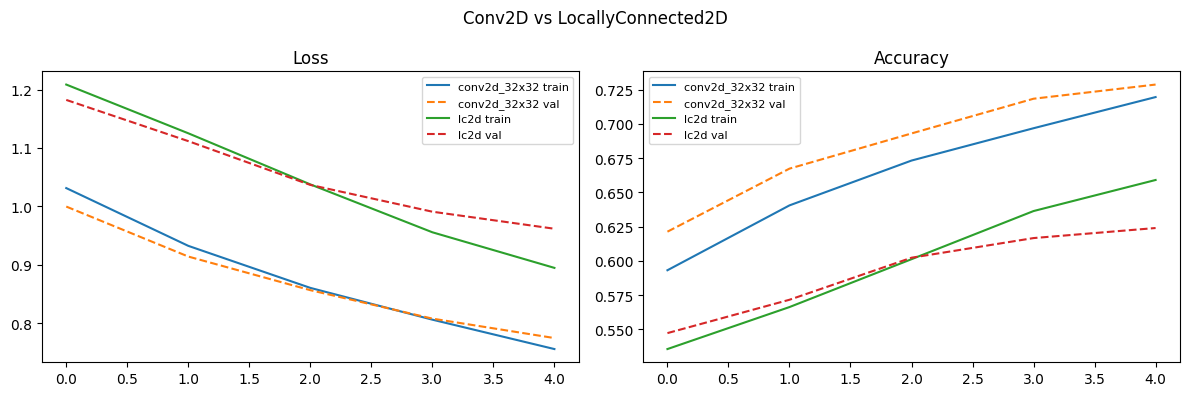

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, hist in [('conv2d_32x32', history.get('conv2D_32x32')),
                   ('lc2d', history.get(lc2D_model.name))
                   ]:
    
    if hist is None:
        continue

    axes[0].plot(hist['loss'],      label=f'{name} train')
    axes[0].plot(hist['val_loss'],  label=f'{name} val', linestyle='--')
    axes[1].plot(hist['accuracy'],     label=f'{name} train')
    axes[1].plot(hist['val_accuracy'], label=f'{name} val', linestyle='--')

axes[0].set_title('Loss'); axes[0].legend(fontsize=8)
axes[1].set_title('Accuracy'); axes[1].legend(fontsize=8)
plt.suptitle('Conv2D vs LocallyConnected2D')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'conv_vs_lc2d.png', bbox_inches='tight')
plt.show()